# Batch Processing in a Container

Built from scratch

## Imports

In [1]:
from Pegasus.api import *
import sys
from pathlib import Path

import logging

logging.basicConfig(level=logging.DEBUG)

## Overall File Structures and Paths

In [2]:
# we specify directories for inputs, executables and outputs
# - directory where to pick up the experimental data.
# - directory where the executables that the workflow uses are placed.
# - directory where the the trained AI models should be placed.

BASE_DIR = Path(".").resolve()
DATA_DIR = Path(BASE_DIR /  "outputs").resolve()
EXECUTABLES_DIR = Path(BASE_DIR / "bin").resolve()
MODEL_DIR = Path(BASE_DIR /  "outputs").resolve() 
OUTPUT_DIR = Path(BASE_DIR /  "outputs").resolve() 
CONTAINERS_DIR = Path(BASE_DIR / "containers").resolve()

# the execution site where you job to run.
# local means the jobs run on ACCESS Pegasus itself.
# condorpool means jobs will run on a node provisioned from an ACCESS site such as jetstream
EXEC_SITE="local"

## Replica Catalog

In [3]:
# --- Replicas -----------------------------------------------------------------
experiment_data = File("experiment_data.h5").add_metadata(creator="sidekick")

rc = ReplicaCatalog()
rc.add_replica("local", experiment_data, DATA_DIR / "experiment_data.h5")

rc.write() # written to ./replicas.yml 

In [4]:
!cat replicas.yml

x-pegasus:
  apiLang: python
  createdBy: sfeister
  createdOn: 07-08-26T22:03:38Z
pegasus: 5.0.4
replicas:
- lfn: experiment_data.h5
  pfns:
  - site: local
    pfn: /home/sfeister/ACCESS-Pegasus-Examples/11-SidekickEasy/outputs/experiment_data.h5
  metadata:
    creator: sidekick


## Transformation Catalog

In [8]:
tc = TransformationCatalog()

# We will run Hello, world in this container
linux_container = Container(
    "linux_container",
    container_type=Container.SINGULARITY,
    image=str(CONTAINERS_DIR / "python_train.sif"),
    image_site="local",
    bypass_staging=True,
)

train = Transformation(
    "train",
    site="local",
    pfn=Path(EXECUTABLES_DIR / "train.py"),
    is_stageable=True,
    container=linux_container,
)


write_os_info = Transformation(
    "write_os_info",
    site="local",
    pfn=Path(EXECUTABLES_DIR / "write_os_info.sh"),
    is_stageable=True,
    container=linux_container,
)

tc.add_containers(linux_container)
tc.add_transformations(write_os_info, train)
tc.write()

In [9]:
!cat transformations.yml

x-pegasus:
  apiLang: python
  createdBy: sfeister
  createdOn: 07-08-26T22:03:56Z
pegasus: 5.0.4
transformations:
- name: write_os_info
  sites:
  - name: local
    pfn: /home/sfeister/ACCESS-Pegasus-Examples/11-SidekickEasy/bin/write_os_info.sh
    type: stageable
    container: linux_container
- name: train
  sites:
  - name: local
    pfn: /home/sfeister/ACCESS-Pegasus-Examples/11-SidekickEasy/bin/train.py
    type: stageable
    container: linux_container
containers:
- name: linux_container
  type: singularity
  image: /home/sfeister/ACCESS-Pegasus-Examples/11-SidekickEasy/containers/python_train.sif
  bypass: true
  image.site: local


## Our test job

In [10]:
os_info = File("os_info.txt")
ridge_model = File("ridge_model.joblib")

write_os_info_job = Job(write_os_info)
write_os_info_job.add_args(os_info)
write_os_info_job.add_outputs(os_info, stage_out=True)


train_job = Job(train)
train_job.add_args(f"-i {experiment_data}", f"-o {ridge_model}")
train_job.add_inputs(experiment_data)
train_job.add_outputs(ridge_model, stage_out=True)

Job(transformation=train)

## Assemble Plan

In [11]:
# the execution site where you job to run.
# local means the jobs run on ACCESS Pegasus itself.
# condorpool means jobs will run on a node provisioned from an ACCESS site such as jetstream
EXEC_SITE="local"

# --- Workflow -----------------------------------------------------------------
wf = Workflow("python-train-test")


wf.add_jobs(write_os_info_job)    
wf.add_jobs(train_job)    

try:
    wf.write()

except PegasusClientError as e:
    print(e)
    raise

INFO:Pegasus.api.workflow:python-train-test added Job(_id=ID0000001, transformation=write_os_info)
INFO:Pegasus.api.workflow:python-train-test added Job(_id=ID0000002, transformation=train)
INFO:Pegasus.api.workflow:inferring python-train-test dependencies
INFO:Pegasus.api.workflow:workflow python-train-test with 2 jobs generated and written to workflow.yml


INFO:Pegasus.api.workflow:inferring python-train-test dependencies
INFO:Pegasus.api.workflow:workflow python-train-test with 2 jobs generated and written to workflow.yml

####################
# pegasus-graphviz #
####################


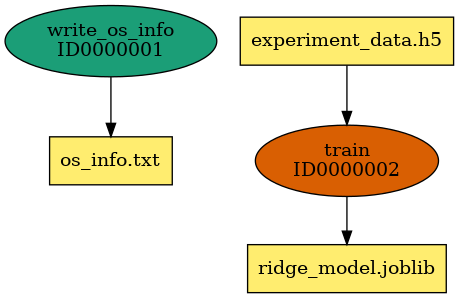

In [13]:
# --- Visualize the Workflow ---------------------------------------------------
try:
    wf.write()
    wf.graph(include_files=True, label="xform-id", output="graph.png")
except PegasusClientError as e:
    print(e)

# view rendered workflow
from IPython.display import Image
Image(filename='graph.png')

In [12]:
# --- Plan Workflow ------------------------------------------------------------
# This creates the submit directory and Condor/DAG files,
# but it does NOT submit the workflow yet.

try:
    wf.plan(
        sites=[EXEC_SITE],
        output_dir=OUTPUT_DIR,
        submit=True,
    )

except PegasusClientError as e:
    print(e)
    raise


################
# pegasus-plan #
################
2026.07.08 22:04:00.742 UTC:
2026.07.08 22:04:00.748 UTC:   -----------------------------------------------------------------------
2026.07.08 22:04:00.753 UTC:   File for submitting this DAG to HTCondor           : python-train-test-0.dag.condor.sub
2026.07.08 22:04:00.758 UTC:   Log of DAGMan debugging messages                   : python-train-test-0.dag.dagman.out
2026.07.08 22:04:00.763 UTC:   Log of HTCondor library output                     : python-train-test-0.dag.lib.out
2026.07.08 22:04:00.769 UTC:   Log of HTCondor library error messages             : python-train-test-0.dag.lib.err
2026.07.08 22:04:00.774 UTC:   Log of the life of condor_dagman itself            : python-train-test-0.dag.dagman.log
2026.07.08 22:04:00.779 UTC:
2026.07.08 22:04:00.784 UTC:   -no_submit given, not submitting DAG to HTCondor. You can do this with:
2026.07.08 22:04:00.795 UTC:   ----------------------------------------------------------------

In [14]:
wf.wait()

[#########################] 100.0% ..Success (Unready: 0, Completed: 10, Queued: 0, Running: 0, Failed: 0)


In [15]:
wf.analyze()


####################
# pegasus-analyzer #
####################

************************************Summary*************************************

Submit Directory   : /home/sfeister/ACCESS-Pegasus-Examples/11-SidekickEasy/sfeister/pegasus/python-train-test/run0005
Workflow Status    : success
Total jobs         :     10 (100.00%)
# jobs succeeded   :     10 (100.00%)
# jobs failed      :      0 (0.00%)
# jobs held        :      0 (0.00%)
# jobs unsubmitted :      0 (0.00%)

**************************************Done**************************************

pegasus-analyzer: end of status report

